1. Project Title

## Loan Approval Analysis

2. Objective

## Project Objective
The  objective of this project is to analyze historical loan application data and identify the major factors associated with loan approval.
The analysis covers data loading and understanding, data quality assessment, missing value treatment, duplicate detection, exploratory data analysis,
applicant and loan characteristics, feature engineering, relationship analysis, statistical visualization, business-oriented analysis, and key business insights.

    


3. Import Libraries

## Step 3: Import Required Libraries
The Python libraries required for the analysis are imported at this stage. Pandas is used for data loading, cleaning, transformation, filtering, grouping, and analysis; NumPy is used for numerical operations; Matplotlib is used for creating basic visualizations; and Seaborn is used for statistical and relationship visualizations.   

    
    
    

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")

4. Load Dataset

## Step 4: Load the Dataset
The loan prediction dataset is loaded into a Pandas DataFrame for further analysis.



In [2]:
df = pd. read_csv(r"E:\downloads\loan pred 614 rows and 13 columns.csv")

5. First Five Records

## Step 5: Preview Dataset
We display the first five rows of the dataset to verify that the Loan Approval data has loaded correctly.

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


6. Create Backup

## Step 6: Create a Backup of the Original Dataset
A copy of the original dataset is stored before performing any modifications, allowing us to return to the original data if required. 



In [4]:
df_original = df.copy()
df_original.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


7. Dataset Shape

## Step 7: Dataset Dimensions
We check the number of observations and variables in the dataset. Rows represent loan applications, while columns represent applicant and loan characteristics.    



In [5]:
print("Number of rows:" ,df.shape[0])
print("Number of columns:" ,df.shape[1])

Number of rows: 614
Number of columns: 13


8. Column Names

## Step 8: Inspect Column Names
We inspect all column names to understand the variables available for analysis.

In [6]:
df.columns.tolist()

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status']

9. First Records

## Step 9: Preview the Dataset
The first few records are displayed to understand the structure, format, and values of the dataset.

In [7]:
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


10. Random Sample

## Step 10: Random Sample
A random sample provides another view of the dataset and helps us inspect observations from different parts of the DataFrame.

In [8]:
df.sample(10, random_state=42)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
350,LP002139,Male,Yes,0,Graduate,No,9083,0.0,228.0,360.0,1.0,Semiurban,Y
377,LP002223,Male,Yes,0,Graduate,No,4310,0.0,130.0,360.0,NaN,Semiurban,Y
163,LP001570,Male,Yes,2,Graduate,No,4167,1447.0,158.0,360.0,1.0,Rural,Y
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
132,LP001478,Male,No,0,Graduate,No,2718,0.0,70.0,360.0,1.0,Semiurban,Y
578,LP002877,Male,Yes,1,Graduate,No,1782,2232.0,107.0,360.0,1.0,Rural,Y
316,LP002035,Male,Yes,2,Graduate,No,3717,0.0,120.0,360.0,1.0,Semiurban,Y
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
340,LP002115,Male,Yes,3+,Not Graduate,No,2647,1587.0,173.0,360.0,1.0,Rural,N
77,LP001259,Male,Yes,1,Graduate,Yes,1000,3022.0,110.0,360.0,1.0,Urban,N


11. Dataset Information

## Step 11: Dataset Information
The info() method provides the column names, data types, number of null values and memory usage of the dataset. This helps identify missing values and columns that may require data type conversion.


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


12. Statistical Summary

## Step 12: Statistical Summary of Numerical Variables
The describe() method provides descriptive statistics such as the mean. standard deviation, minimum, maximum, and quartiles.
These statistics help us understand the distribution of numerical variables.



In [10]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


13. Categorical Summary

## Step 13: Statistical Summary of Categorical Variables
We examine categorical variables to understand their unique values, most frequent category, and frequency.

In [11]:
df.describe(include="string")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


14. Duplicate Check

## Step 14: Check for Duplicate Records
Duplicate records can cause the same loan application to be counted more than once, so we check the number of completely duplicated rows
in the dataset.



In [12]:
print("Duplicate rows:" ,df.duplicated().sum())

Duplicate rows: 0


15. Remove Duplicates 

## Step 15: Remove Duplicate Records
Duplicate records are removed while keeping the first occurence. ensuring that duplicate applications do not distort the analysis.  

  
    

In [13]:
df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (614, 13)


16. Missing Values

## Step 16: Missing Value Analysis
 We calculate the number of missing values in every column. Missing value analysis is an important part of data-quality assessment before performing further analysis.




In [14]:
missing_values = df.isnull().sum()
missing_values

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

17. Missing Percentage

## Step 17: Missing Value Percentage
The percentage of missing observations is calculated for each column, which helps us understand the severity of missing data across variables. 



In [15]:
misssing_percentage = (
    df.isnull().sum()
    .div(len(df))
    .mul(100)
    .sort_values(ascending=False))
misssing_percentage

Credit_History       8.143322
Self_Employed        5.211726
LoanAmount           3.583062
Dependents           2.442997
Loan_Amount_Term     2.280130
Gender               2.117264
Married              0.488599
Education            0.000000
Loan_ID              0.000000
CoapplicantIncome    0.000000
ApplicantIncome      0.000000
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

18. Standardize Column Names

## Step 18: Standardize Column Names
Column names are converted to lowercase and spaces are replaced with underscores to create consistent and Python-friendly column names.



In [16]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
df.columns.tolist()

['loan_id',
 'gender',
 'married',
 'dependents',
 'education',
 'self_employed',
 'applicantincome',
 'coapplicantincome',
 'loanamount',
 'loan_amount_term',
 'credit_history',
 'property_area',
 'loan_status']

19. Inspect Categorical Variables

## Step 19: Inspect Categorical Variables
We identify all categorical columns in the dataset. Categorical variables contain groups or labels rather than continuous numerical measurements.    



In [17]:
categorical_columns =df.select_dtypes(include="string").columns

categorical_columns.tolist()

['loan_id',
 'gender',
 'married',
 'dependents',
 'education',
 'self_employed',
 'property_area',
 'loan_status']

20. Unique values

## Step 20: Inspect Unique Categories
We examine the unique values in each categorical column. This helps identify unexpected categories, inconsistent values, or unusual entries.    

   

In [70]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


loan_id
<StringArray>
['LP001002', 'LP001003', 'LP001005', 'LP001006', 'LP001008', 'LP001011',
 'LP001013', 'LP001014', 'LP001018', 'LP001020',
 ...
 'LP002959', 'LP002960', 'LP002961', 'LP002964', 'LP002974', 'LP002978',
 'LP002979', 'LP002983', 'LP002984', 'LP002990']
Length: 614, dtype: str

gender
<StringArray>
['Male', 'Female', nan]
Length: 3, dtype: str

married
<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

dependents
<StringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str

education
<StringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str

self_employed
<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

property_area
<StringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype: str

loan_status
<StringArray>
['Y', 'N']
Length: 2, dtype: str


21. Category Frequencies

## Step 21: Frequency of Categorical Values
We calculate the frequency of each category in every categorical variable, which helps us understand the composition of the applicant population.  

  

In [71]:
for column in categorical_columns:
    print(f"\n{column}")
print(df[column].value_counts(dropna=False))    


loan_id

gender

married

dependents

education

self_employed

property_area

loan_status
loan_status
Y    422
N    192
Name: count, dtype: int64


22. Categorical Missing Values

## Step 22: Handle Missing Categorical Values
Missing values in categorical variables are replaced with the mode, which is the most frequently occuring category. This approach is suitable when the proportion of missing values is relatively small.





In [72]:
categorical_columns_to_fill = [
    "gender",
    "married",
    "dependents",
    "self_employed",
    "credit_history"
]
for column in categorical_columns_to_fill:
    if column in df.columns and df[column].isnull().sum() > 0:
        df[column] =df[column].fillna(df[column].mode()[0])
           


In [73]:
df[categorical_columns_to_fill].isnull().sum()

gender            0
married           0
dependents        0
self_employed     0
credit_history    0
dtype: int64

23. Numerical Missing Values

## Step 23: Handle Missing Numerical Values
Missing numerical values are replaced using the median. The median is less sensitive to extreme values than the mean and is therefore useful for skewed financial variables.    
    



In [74]:
numerical_columns_to_fill = [
    "loanamount",
    "loan_amount_term"
]
for column in numerical_columns_to_fill:
    if(
        column in df.columns 
        and df[column].isnull().sum() > 0
    ):

        df[column] = df[column].fillna( df[column].median())
           


24. Verify Missing Values

## Step 24: Verify Missing-Value Treatment
We check the missing values again after imputation to confirm that the cleaning process has been completed successfully.

In [75]:
df.isnull().sum()

loan_id              0
gender               0
married              0
dependents           0
education            0
self_employed        0
applicantincome      0
coapplicantincome    0
loanamount           0
loan_amount_term     0
credit_history       0
property_area        0
loan_status          0
dtype: int64

25. Loan Status

## Step 25: Loan Approval Status
'loan_status' is the target variable. We inspect its unique values to understand how loan applications are classified as approved or rejected.    
  

In [76]:
df["loan_status"].unique()

<StringArray>
['Y', 'N']
Length: 2, dtype: str

26. Approval Count

## Step 26: loan Approval Distribution
We count the number of approved and rejected loan applications. This establishes the overall distribution of the target variable. 
    
    

In [77]:
loan_status_counts = df["loan_status"].value_counts()
loan_status_counts

loan_status
Y    422
N    192
Name: count, dtype: int64

27. Approval Percentage

## Step 27: Overall Loan Approval Rate
We calculate the percentage of applications that were approved and rejected. This provides a baseline for comparing loan approval outcomes across different applicant groups.  

  

In [78]:
loan_status_percentage = (
    df["loan_status"]
    .value_counts(normalize=True)
    .mul(100)
)
loan_status_percentage

loan_status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

28. Gender vs Approval

## Step 28: Gender vs Loan Approval
We calculate the approval percentage within each gender group. Using percentages allows us to compare groups more fairly than raw counts.    

 

In [79]:
gender_approval = pd.crosstab(
    df["gender"],
    df["loan_status"],
    normalize="index"
) * 100
gender_approval

loan_status,N,Y
gender,,
Female,33.035714,66.964286
Male,30.876494,69.123506


29. Marital Status

## Step 29: Marital Status vs Loan Approval
We compare historical approval rates between married and unmarried applicants.

In [80]:
married_approval = pd.crosstab(
    df["married"],
    df["loan_status"],
    normalize="index"
) * 100
married_approval

loan_status,N,Y
married,,
No,37.089202,62.910798
Yes,28.179551,71.820449


30. Education

## Step 30: Education vs Loan Approval
We compare historical approval rates between graduate and non-graduates applicants.

In [81]:
education_approval = pd.crosstab(
    df["education"],
    df["loan_status"],
    normalize="index"
) * 100
education_approval

loan_status,N,Y
education,,
Graduate,29.166667,70.833333
Not Graduate,38.805970,61.194030


31. Self-Employment

## Step 31: Self-Employment vs Loan Approval
We compare historical approval rates between self-employed and non-self-employed applicants.

In [82]:
self_employed_approval = pd.crosstab(
    df["self_employed"],
    df["loan_status"],
    normalize="index"
) * 100
self_employed_approval

loan_status,N,Y
self_employed,,
No,31.203008,68.796992
Yes,31.707317,68.292683


32. Property Area

## Step 32: Property Area vs Loan Approval
We compare approval rates across urban, semiurban, and rural property areas.

In [83]:
property_approval = pd.crosstab(
    df["property_area"],
    df["loan_status"],
    normalize="index"
) * 100
property_approval

loan_status,N,Y
property_area,,
Rural,38.547486,61.452514
Semiurban,23.175966,76.824034
Urban,34.158416,65.841584


33. Dependents

## Step 33: Dependents vs Loan Approval
We calculate approval rates for different number of dependents. This helps identify whether applicant family responsibilities are associated
with different historical loan outcomes.

In [84]:
dependents_approval = pd.crosstab(
    df["dependents"],
    df["loan_status"],
    normalize="index"
) * 100
dependents_approval

loan_status,N,Y
dependents,,
0,31.388889,68.611111
1,35.294118,64.705882
2,24.752475,75.247525
3+,35.294118,64.705882


34. Credit History

## Step 34: Credit History vs Loan Approval
We calculate the approval rate for each credit-history group. This is particularly important because credit history has a strong relationship with loan approval in this dataset.



In [85]:
credit_approval = pd.crosstab(
    df["credit_history"],
    df["loan_status"],
    normalize="index"
) * 100
credit_approval

loan_status,N,Y
credit_history,,
0.0,92.134831,7.865169
1.0,20.952381,79.047619


35. Income Statistics

## Step 35: Applicant Income by loan Status
We compare descriptive statistics of applicant income for approved and rejected applications. This allows us to compare the central tendency and spread of income between the two groups.

  

In [86]:
df.groupby("loan_status")["applicantincome"].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
N,192.0,5446.078125,6819.558528,150.0,2885.0,3833.5,5861.25,81000.0
Y,422.0,5384.068720,5765.441615,210.0,2877.5,3812.5,5771.50,63337.0


36. Loan Amount Statistics

## Step 36: Loan Amount by loan Status
We compare descriptive statistics of requested loan amounts between approved and rejected applications.

In [87]:
df.groupby("loan_status")["loanamount"].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
N,192.0,149.890625,83.529056,9.0,102.75,128.0,173.0,570.0
Y,422.0,143.869668,84.400468,17.0,100.00,128.0,160.0,700.0


37. Total Income

## Step 37: Create Total Income
Applicant income and co-applicant income are combined to create a total income. This provides a broader measure of the household income recorded in the application.  



In [88]:
df["total_income"] = (
    df["applicantincome"] +
    df["coapplicantincome"]
)
df[
    [
        "applicantincome",
        "coapplicantincome",
        "total_income"
    ]
    ].head()
        


,applicantincome,coapplicantincome,total_income
0,5849,0.0,5849.0
1,4583,1508.0,6091.0
2,3000,0.0,3000.0
3,2583,2358.0,4941.0
4,6000,0.0,6000.0


38. Income Category

## Step 38: Create Income Categories
Total income is divided into four quartile-based groups. This segmentation creates approximately equal-sized groups and makes income easier to compare in business analysis.

  

In [89]:
df["income_category"] = pd.qcut(
    df["total_income"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
         "Medium-High",
         "High"
    ]
)
df["income_category"].value_counts()
        
    

income_category
Low            155
High           154
Medium-High    153
Medium-Low     152
Name: count, dtype: int64

39. Loan-to-Income Ratio

## Step 39: Create Loan-to-Income Ratio
The loan-to-income ratio compares the requested loan amount with the applicant's total recorded income. A higher ratio means the requested loan is relatively large compared with recorded income. A small constant is added to the denominator to avoid division by zero when an applicant has zero recorded income.   






In [90]:
df["loan_to_income_ratio"] = (
    df["loanamount"] /
    (df["total_income"] + 1)
)
df["loan_to_income_ratio"].describe()

count    614.000000
mean       0.023872
std        0.008704
min        0.002523
25%        0.019218
50%        0.024126
75%        0.028147
max        0.082685
Name: loan_to_income_ratio, dtype: float64

40. Income Category Approval

## Step 40: Income Category vs Loan Approval
We calculate approval rates across the four income categories. This allows us to examine whether historical approval outcomes differ across income segments.   



In [91]:
income_approval = pd.crosstab(
    df["income_category"],
    df["loan_status"],
    normalize="index"
) * 100
income_approval

loan_status,N,Y
income_category,,
Low,32.258065,67.741935
Medium-Low,31.578947,68.421053
Medium-High,28.758170,71.241830
High,32.467532,67.532468


41. Property Area Summary

## Step 41: Property Area Business Summary

For each property area, we calculate the number of applications, average total income, average loan amount, and approval rate. This provides a compact business summary of applicant outcomes across different property areas.    



 

In [92]:
property_summary = (
    df.groupby("property_area")
       .agg(
           applications=("loan_id","count"),
            average_income=("total_income","mean"),
            average_loan_amount=("loanamount","mean"),
            approval_rate=(
               "loan_status",
               lambda x: (x =="Y").mean() * 100,
                   ),
           )
           .sort_values(
               "approval_rate",
                ascending=False,
           )
       )
    
property_summary               

,applications,average_income,average_loan_amount,approval_rate
property_area,,,,
Semiurban,233,6812.394850,145.128755,76.824034
Urban,202,7114.598020,141.425743,65.841584
Rural,179,7199.620782,151.446927,61.452514


42. Credit History Summary

## Step 42: Credit History Business Summary

We calculate application volume, average income, average loan amount, and approval rate for each credit-history group.

In [93]:
credit_summary = (
    df.groupby("credit_history")
       .agg(
           applications=("loan_id","count"),
average_income=("total_income","mean"),
average_loan_amount=("loanamount","mean"),
           approval_rate=(
               "loan_status",
               lambda x: (x =="Y").mean() * 100,
                   )
           )
           .sort_values(
               "approval_rate",
                ascending=False
           )
       )
    
credit_summary               

,applications,average_income,average_loan_amount,approval_rate
credit_history,,,,
1.0,525,6991.323657,145.731429,79.047619
0.0,89,7221.617978,145.876404,7.865169


43. Education Summary

## Step 43: Education Business Summary
We compare application volume, average income, average loan amount, and approval rate across education categories.

In [94]:
education_summary = (
    df.groupby("education")
       .agg(
           applications=("loan_id","count"),
average_income=("total_income","mean"),
average_loan_amount=("loanamount","mean"),
           approval_rate=(
               "loan_status",
               lambda x: (x =="Y").mean() * 100,
                   )
           )
           .sort_values(
               "approval_rate",
                ascending=False
           )
       )
    
credit_summary               

,applications,average_income,average_loan_amount,approval_rate
credit_history,,,,
1.0,525,6991.323657,145.731429,79.047619
0.0,89,7221.617978,145.876404,7.865169


44. Income Quartiles

## Step 44: Applicant Income Quartiles
Once we calculate the quartiles, they help us understand the distribution of applicant income and identify unusually high or low observations.



In [95]:
df["applicantincome"].quantile([0.25, 0.50, 0.75]
 )

0.25    2877.5
0.50    3812.5
0.75    5795.0
Name: applicantincome, dtype: float64

45. Loan Amount Quartiles

## Step 45: Loan Amount Quartiles
We calculate the first quartile, median, and third quartile of loan amount to understand its distribution.

In [96]:
df["loanamount"].quantile([0.25, 0.50, 0.75]
 )

0.25    100.25
0.50    128.00
0.75    164.75
Name: loanamount, dtype: float64

46. Identify High Loan Amounts

## Step 46: Identify Potentially High Loan Amounts
The Interquartile Range(IQR) method is used to identify observations with unusually high loan amounts. This is an exploratory step and does not automatically mean that these observations should be removed.    



In [97]:
Q1 =df["loanamount"].quantile(0.25)
Q3 =df["loanamount"].quantile(0.75)
IQR = Q3-Q1

upper_limit =  Q3 + 1.5 * IQR

high_loan_amounts = df[
    df["loanamount"] > upper_limit
    ]
print("upper otlier limit:", upper_limit)
print("Potential high-loan observations:",
len(high_loan_amounts))
      


upper otlier limit: 261.5
Potential high-loan observations: 41


47. Loan Approval Distribution

## Step 47: Loan Approval Distribution 
A bar chart is used to visualize the number of approved and rejected loan applications. This provides a quick overview of the target variable distribution.  

   

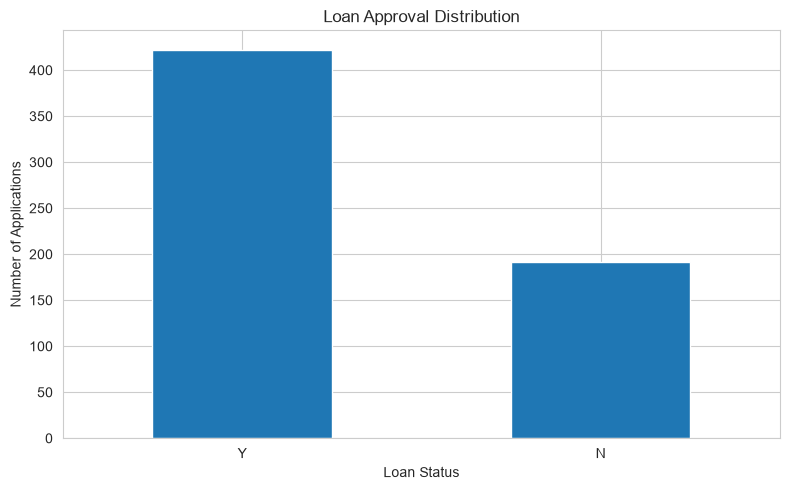

In [121]:
plt.figure(figsize=(8,5))
loan_status_counts.plot(
    kind="bar")
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()




## Business Insights
- Approved loan applications are higher than rejected loan applications in the dataset.
- The distribution indicates that a larger share of applications received loan approval than rejection.


46. Applicant Income Distribution

## Step 46: Applicant Income Distribution
A histogram is used to examine the distribution of applicant income. This helps identify skewness and unusually high income observations.    



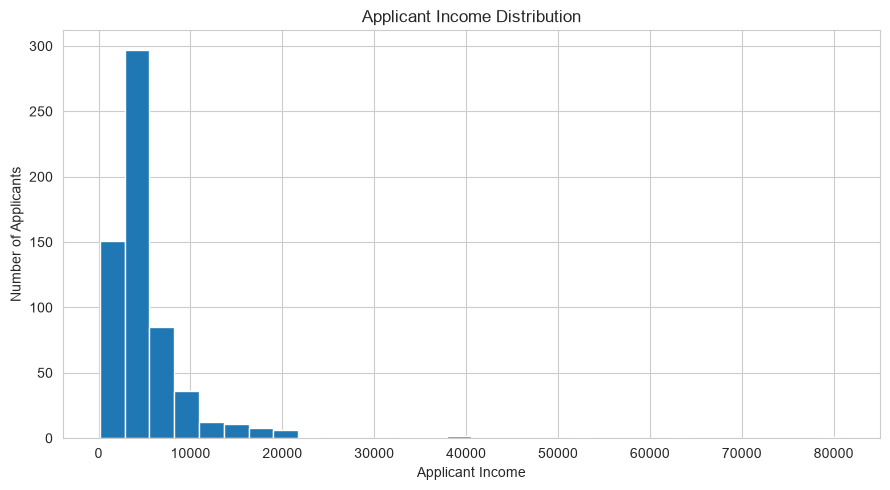

In [122]:
plt.figure(figsize=(9,5))
plt.hist(
    df["applicantincome"],
    bins=30
)
plt.title("Applicant Income Distribution")
plt.xlabel("Applicant Income")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()



## Business Insights
- Applicant income is concentrated within the lower-to-middle income range, with fewer applicants at very high income levels.
- The distribution indicates that the applicant base is primarily composed of borrowers with relatively moderate income levels.    

47. Loan Amount Distribution

## Step 47: Loan Amount Distribution
A histogram is used to understand the distribution of requested loan amounts.

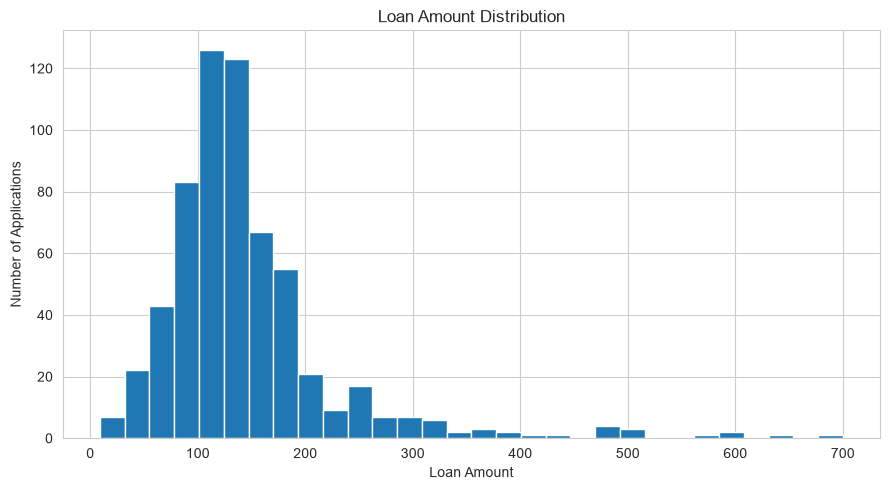

In [123]:
plt.figure(figsize=(9,5))
plt.hist(
    df["loanamount"],
    bins=30
)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applications")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()



## Business Insights
- Loan amounts are concentrated within the lower-to-moderate range, with fewer applications involving very high loan amounts.
- This indicates that most applicants are seeking relatively moderate loan amounts rather than exceptionally large loans.    

48. Approval Rate by Property Area

## Step 48: Approval Rate by Property Area
We calculate the approval rate for each property area and visualize the resulting comparison using a bar chart.

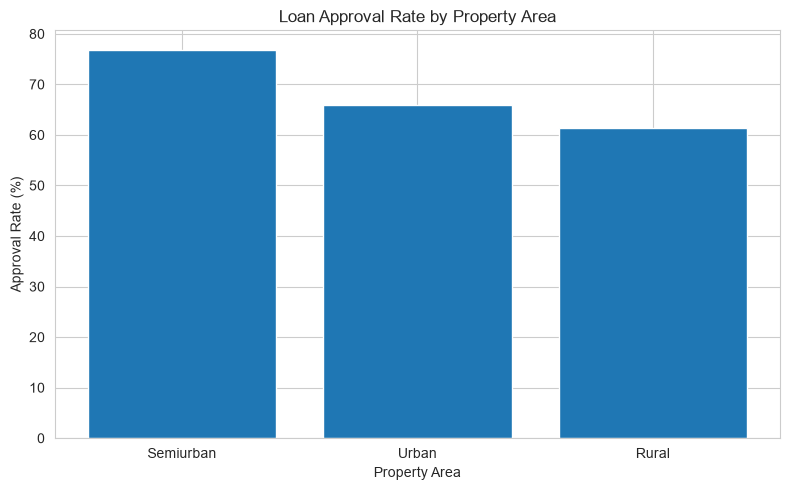

In [124]:
property_rate = (
    df.groupby("property_area")
        ["loan_status"]
        .apply(lambda x: (x == "Y").mean() * 100)
        .sort_values(ascending=False))
plt.figure(figsize=(8,5))
plt.bar(
    property_rate.index,
    property_rate.values
)
plt.title("Loan Approval Rate by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Approval Rate (%)")


plt.tight_layout()
plt.show()


## Business Insights
- Loan approval rates differ across different property areas.
- This indicates that property area is associated with differences in loan approval outcomes.  

49. Loan Approval Count

## Step 49: Loan Approval Count Plot
A Seaborn count plot is used to visualize the number of approved and rejected applications.

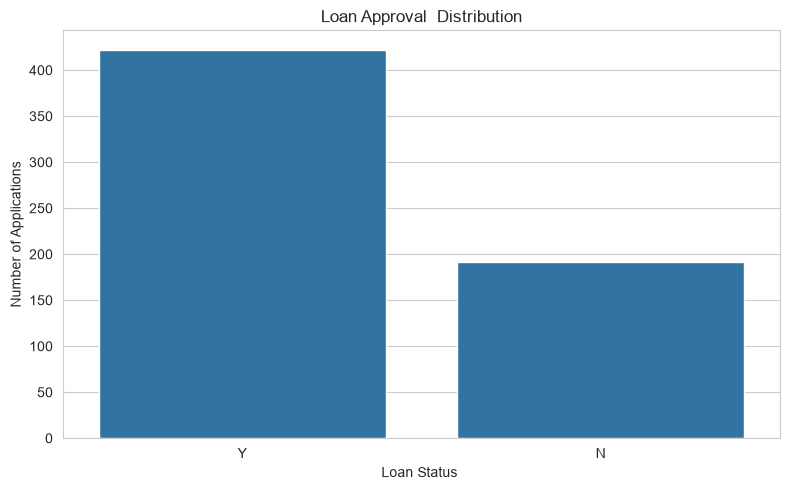

In [125]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="loan_status"
)
plt.title("Loan Approval  Distribution")
plt.xlabel("Loan Status ")
plt.ylabel("Number of Applications")


plt.tight_layout()
plt.show()


## Business Insights
- The number of approved loan applications is higher than the number of rejected applications.
- This indicates that a larger proportion of applicants received loan approval in the dataset.    

50. Approval by Gender

## Step 50: Loan Approval by Gender
A count plot compares approved and rejected applications across gender categories. This shows the volume of loan approval outcomes within each gender category.



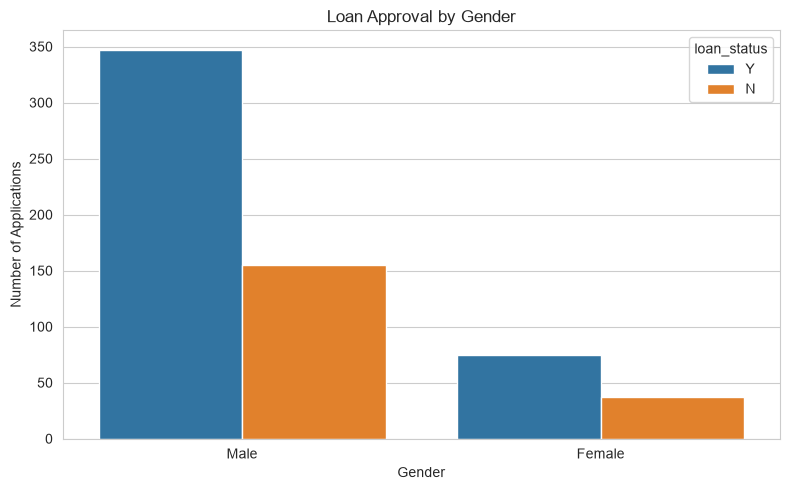

In [126]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="gender",
    hue="loan_status"
)
plt.title("Loan Approval by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Applications")


plt.tight_layout()
plt.show()


 ## Business Insights
- Male applicants account for a larger number of both approved and rejected loans, indicating a higher representation of male applicants in the dataset.
- Approved outcomes vary across genders, highlighting differences in loan approval patterns.    

51. Approval by Education

## Step 51: Loan Approval by Education
We compare approval outcomes across education categories. This helps identify differences in historical application outcomes between the groups.



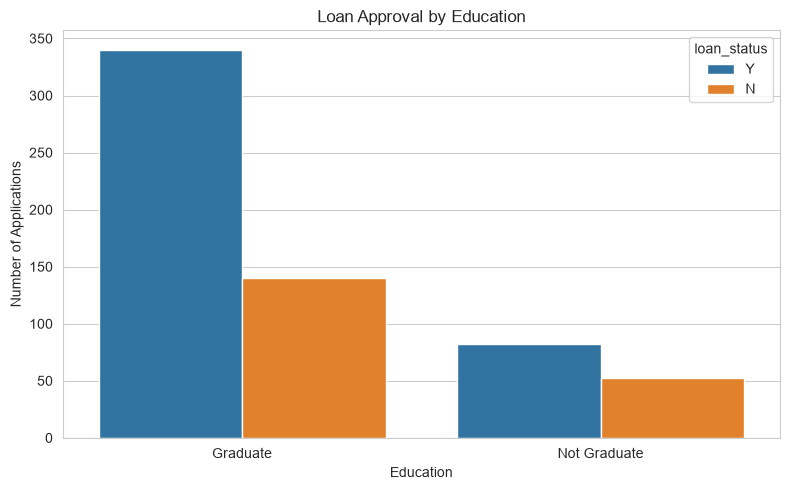

In [127]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="education",
    hue="loan_status"
)
plt.title("Loan Approval by Education")
plt.xlabel("Education")
plt.ylabel("Number of Applications")


plt.tight_layout()
plt.show()


##  Business Insights
- Graduate applicants have a higher number of approved loans compared with non-graduate applicants.
- Education level shows a noticeable difference in loan approval outcomes.    

52. Approval by Property Area

## Step 52: Loan Approval by Property Area
A count plot compares approved and rejected applications across urban, semiurban, and rural property areas.

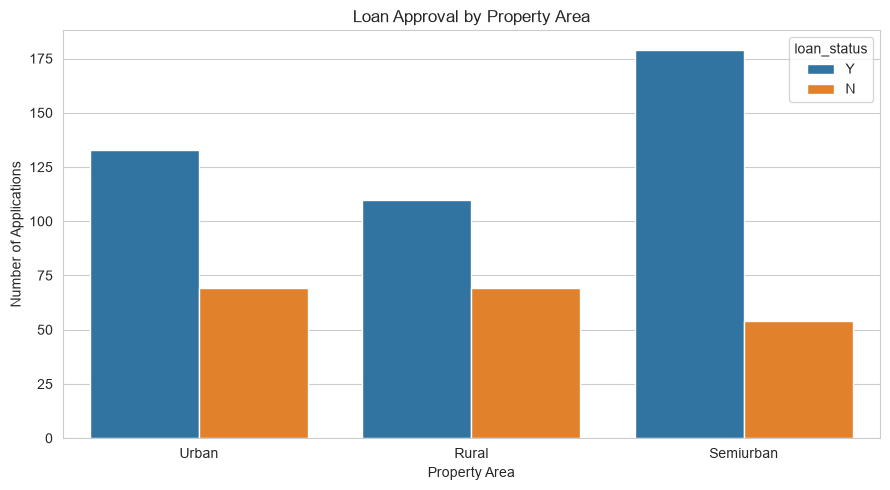

In [128]:
plt.figure(figsize=(9,5))
sns.countplot(
    data=df,
    x="property_area",
    hue="loan_status"
)
plt.title("Loan Approval by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Number of Applications")


plt.tight_layout()
plt.show()

##  Business Insights
- Semiurban applicants have the highest number of approved loans, followed by urban and rural applicants.
- Loan approval outcomes vary across property areas, indicating differences in approval patterns by location.    

53. Credit History vs Approval

## Step 53: Credit History vs Loan Approval
Credit history is one of the most important variables to investigate. This visualization compares the number of approved and rejected applications across credit history categories.    



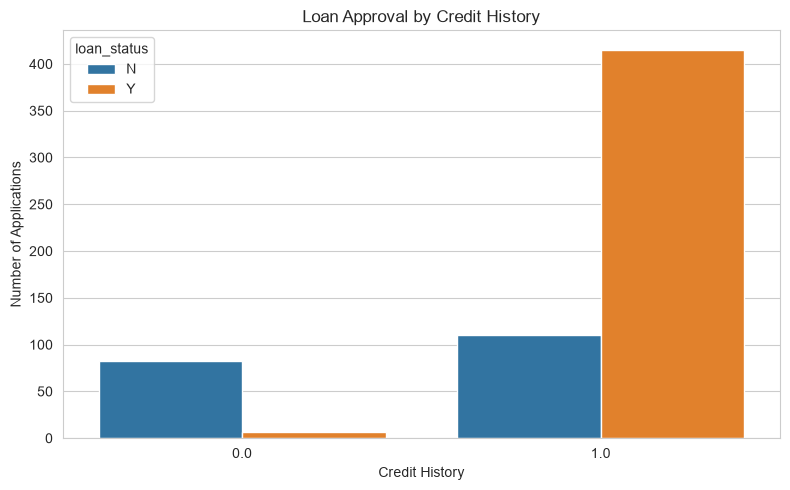

In [129]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="credit_history",
    hue="loan_status"
)
plt.title("Loan Approval by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Number of Applications")


plt.tight_layout()
plt.show()

## Business Insights
- Applicants with a positive credit history have a substantially higher number of approved loans.
- Credit history is a strong indicator of loan approval outcomes in the dataset.    

54. Income vs Approval

## Step 54: Applicant Income by Loan Status
A box plot compares applicant income between approved and rejected applicaions. It allows us to compare median income, the spread of income values, and potential outliers.



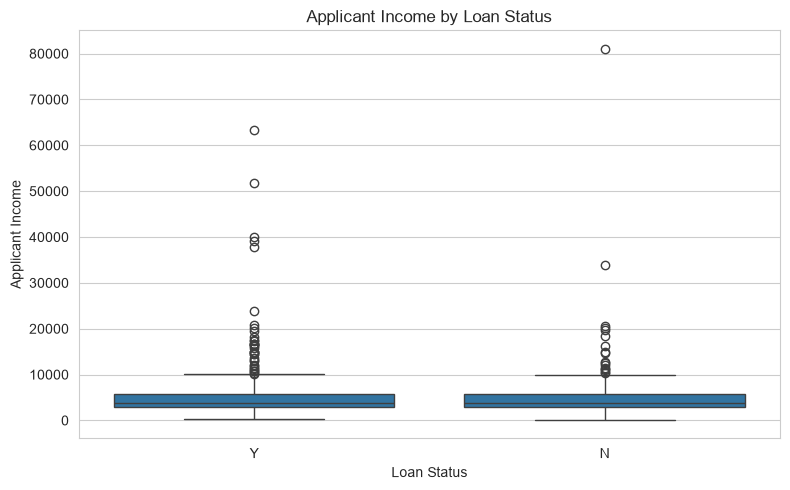

In [130]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="loan_status",
    y="applicantincome"
)
plt.title("Applicant Income by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Applicant Income")


plt.tight_layout()
plt.show()

## Business Insights
- Approved applicants generally show higher applicant income compared with rejected applicants.
- This suggests that applicant income is associated with differences in loan approved outcomes.   

55. Loan Amount vs Approval

## Step 55: Loan Amount by Loan Status
A box plot compares requested loan amounts between approved and rejected applicaions. This helps identify differences in typical loan amount across approval outcomes.



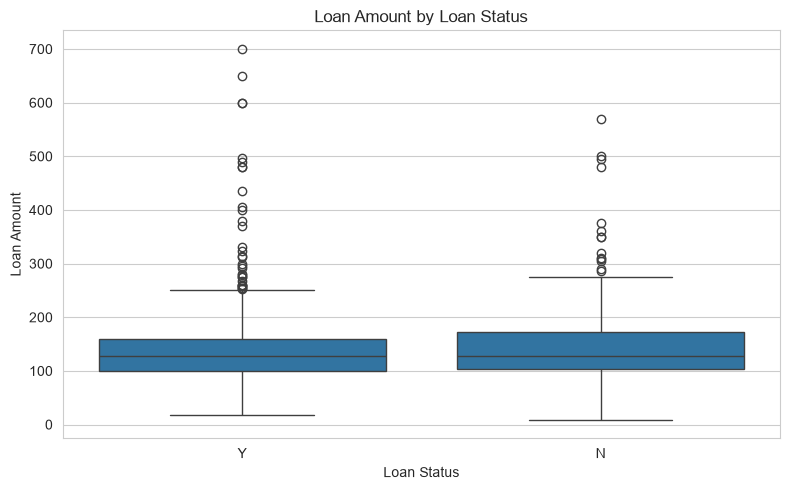

In [131]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="loan_status",
   y="loanamount"
)
plt.title("Loan Amount by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")


plt.tight_layout()
plt.show()

## Business Insights
- Approved applications generally have higher average loan amounts compared with rejected applications.
- Loan amount shows a noticeable difference between approved and rejected applications.    

56. Total Income vs Approval

## Step 56: Total Income by Loan Status
The engineered 'total_income' variable is compared across approved and rejected applications. This provides a broader view of applicants financial capacity. 



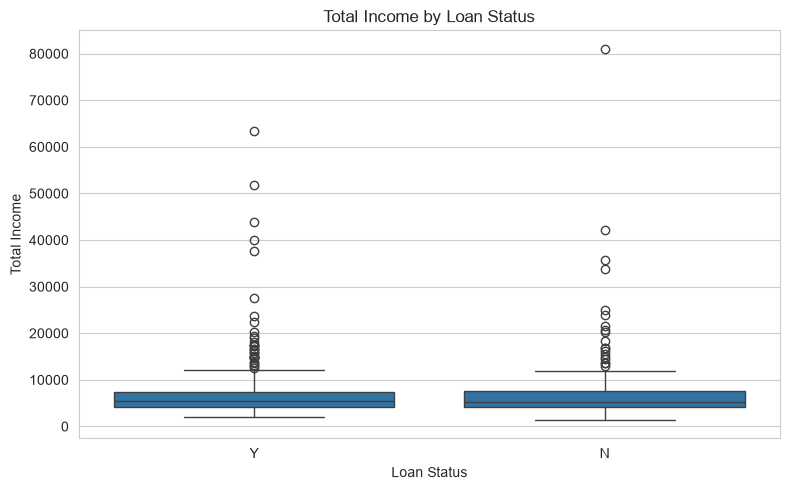

In [132]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="loan_status",
    y="total_income"
)
plt.title("Total Income by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Total Income")


plt.tight_layout()
plt.show()

## Business Insights
- Approved applicants generally have higher total income compared with rejected applicants.
- Higher total income is associated with more favorable loan approval outcomes in the dataset.    

57. Loan-to-Income Ratio

## Step 57: Loan-to-Income Ratio by Loan Status
A box plot compares the loan-to-income ratio between approved and rejected applications. This provides a risk-oriented view of requested loan size relative to recorded income. 

    

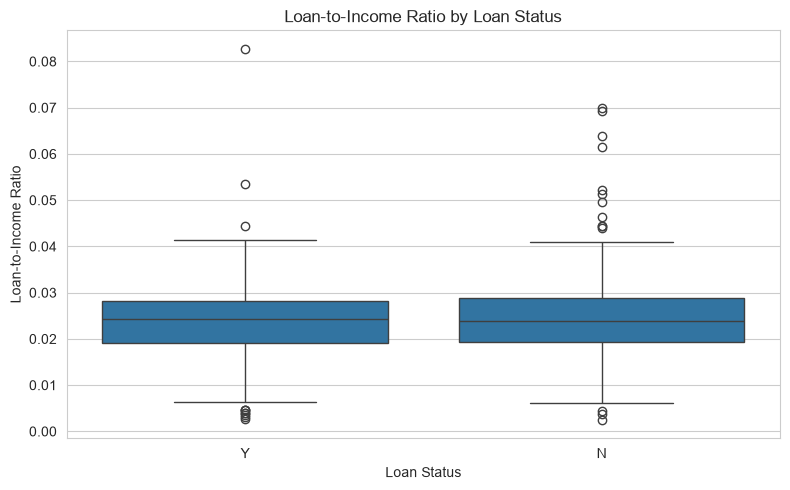

In [133]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="loan_status",
   y="loan_to_income_ratio"
)
plt.title("Loan-to-Income Ratio by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan-to-Income Ratio")


plt.tight_layout()
plt.show()

## Business Insights
- Approved applications generally show a lower loan-to-income ratio compared with rejected applications.
- A lower loan-to-income ratio indicates a relatively lower loan burden compared with the applicant's income.    

58. Income Category vs Approval

## Step 58: Income Category vs Loan Approval
A count plot compares approval outcomes across the four income categories created during featre engineerig.

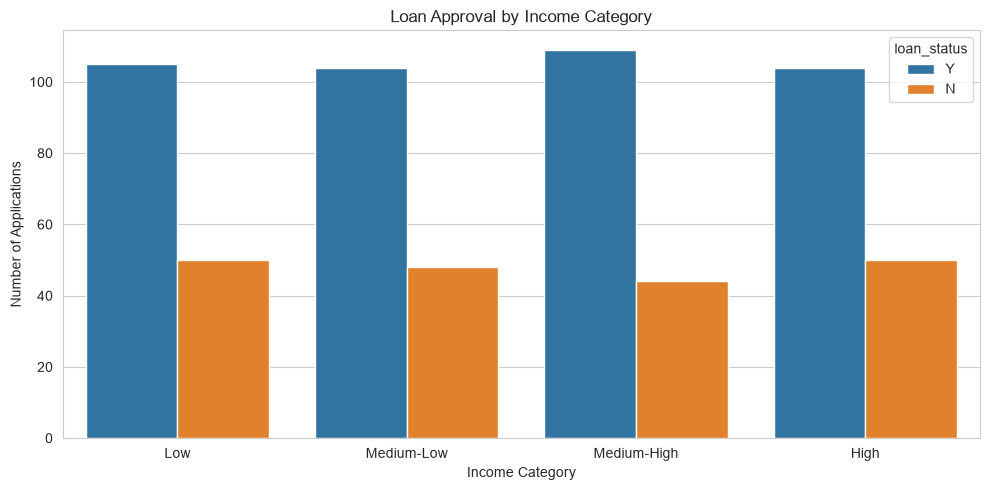

In [134]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x="income_category",
    hue="loan_status"
)
plt.title("Loan Approval by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Number of Applications")


plt.tight_layout()
plt.show()

## Business Insights
- Loan approval rates vary across income categories, with higher-income categories generally showing stronger approval outcomes.
- Income level is associated with differences in loan approval patterns.    

59. Correlation Matrix

## Step 59:  Numerical Correlation Matrix
 Correlation measures the strength of a linear relationship between numerical variables and indicates the direction of the relationship between them. Correlation does not imply causation. 
 
   

In [113]:
numeric_df = df.select_dtypes(
    include=np.number
)
correlation_matrix = numeric_df.corr()
correlation_matrix

,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,total_income,loan_to_income_ratio
applicantincome,1.000000,-0.116605,0.565181,-0.046531,-0.018615,0.893037,-0.317422
coapplicantincome,-0.116605,1.000000,0.189218,-0.059383,0.011134,0.342781,-0.201064
loanamount,0.565181,0.189218,1.000000,0.036960,-0.000607,0.620316,0.153005
loan_amount_term,-0.046531,-0.059383,0.036960,1.000000,-0.004705,-0.070917,0.166317
credit_history,-0.018615,0.011134,-0.000607,-0.004705,1.000000,-0.012563,-0.035162
total_income,0.893037,0.342781,0.620316,-0.070917,-0.012563,1.000000,-0.391336
loan_to_income_ratio,-0.317422,-0.201064,0.153005,0.166317,-0.035162,-0.391336,1.000000


60. Correlation Heatmap

## Step 60: Correlation Heatmap
A Seaborn heat map provides a visual representation of the correlation matrix. Correlation values range from -1 to +1, where +1 indicates a strong positive linear relationship, -1 indicates a strong negative linear relationship, and 0  indicates little or no linear relationship. 




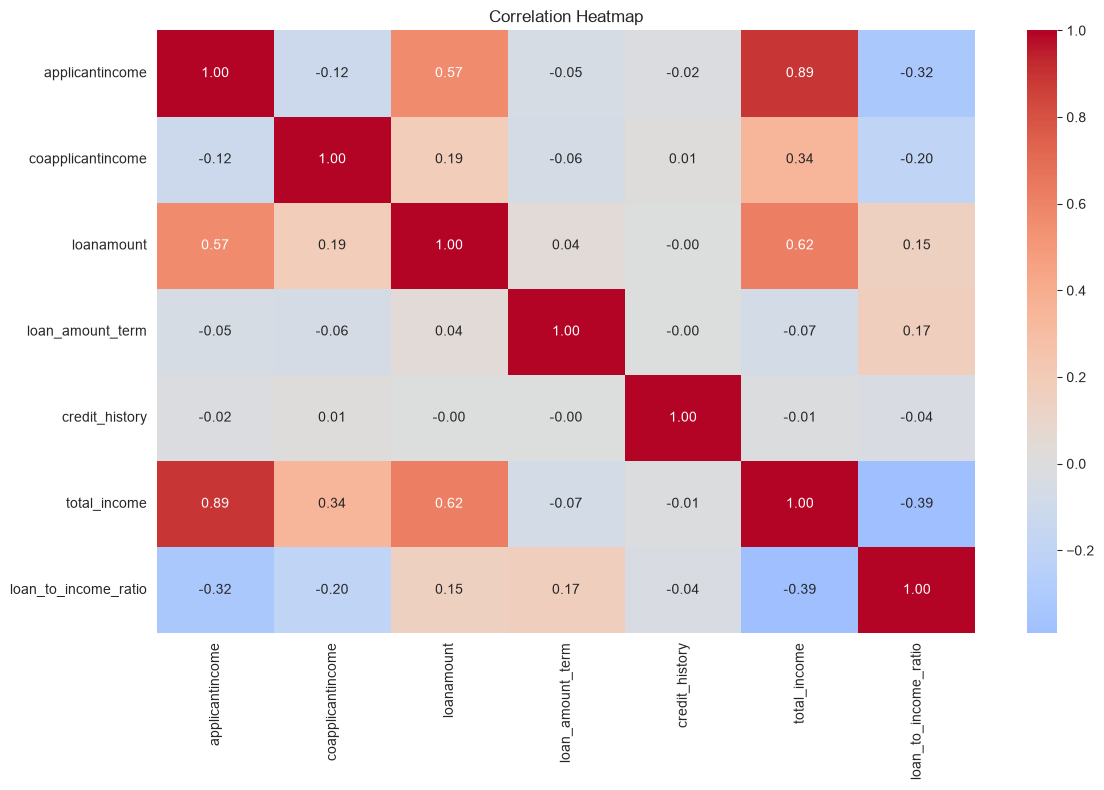

In [114]:
plt.figure(figsize=(12,8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")



plt.tight_layout()
plt.show()

## Business Insights
- The heat map shows that most numerical variables have weak to moderate correlations with each other, indicating that they generally capture
different aspects of an applicant's financial profile.
- Applicant Income and Coapplicant Income show a relatively weak relationship, while Loan Amount has a more noticeable positive relationship
with Applicant Income, indicating that higher-income applicants tend to apply for larger loans.
- Credit History has a relatively weak linear correlation with the other numerical variables, suggesting that credit history provides additional
information beyond income and loan amount. 


61. Pair Plot

## Step 61: Pair Plot of Important Numerical Variables
A pair plot allows us to examine relationships and distributions among multiple numerical variables simultaneously. Loan status is used as the hue so that differences between approved and rejected applications can be visually explored.   

   

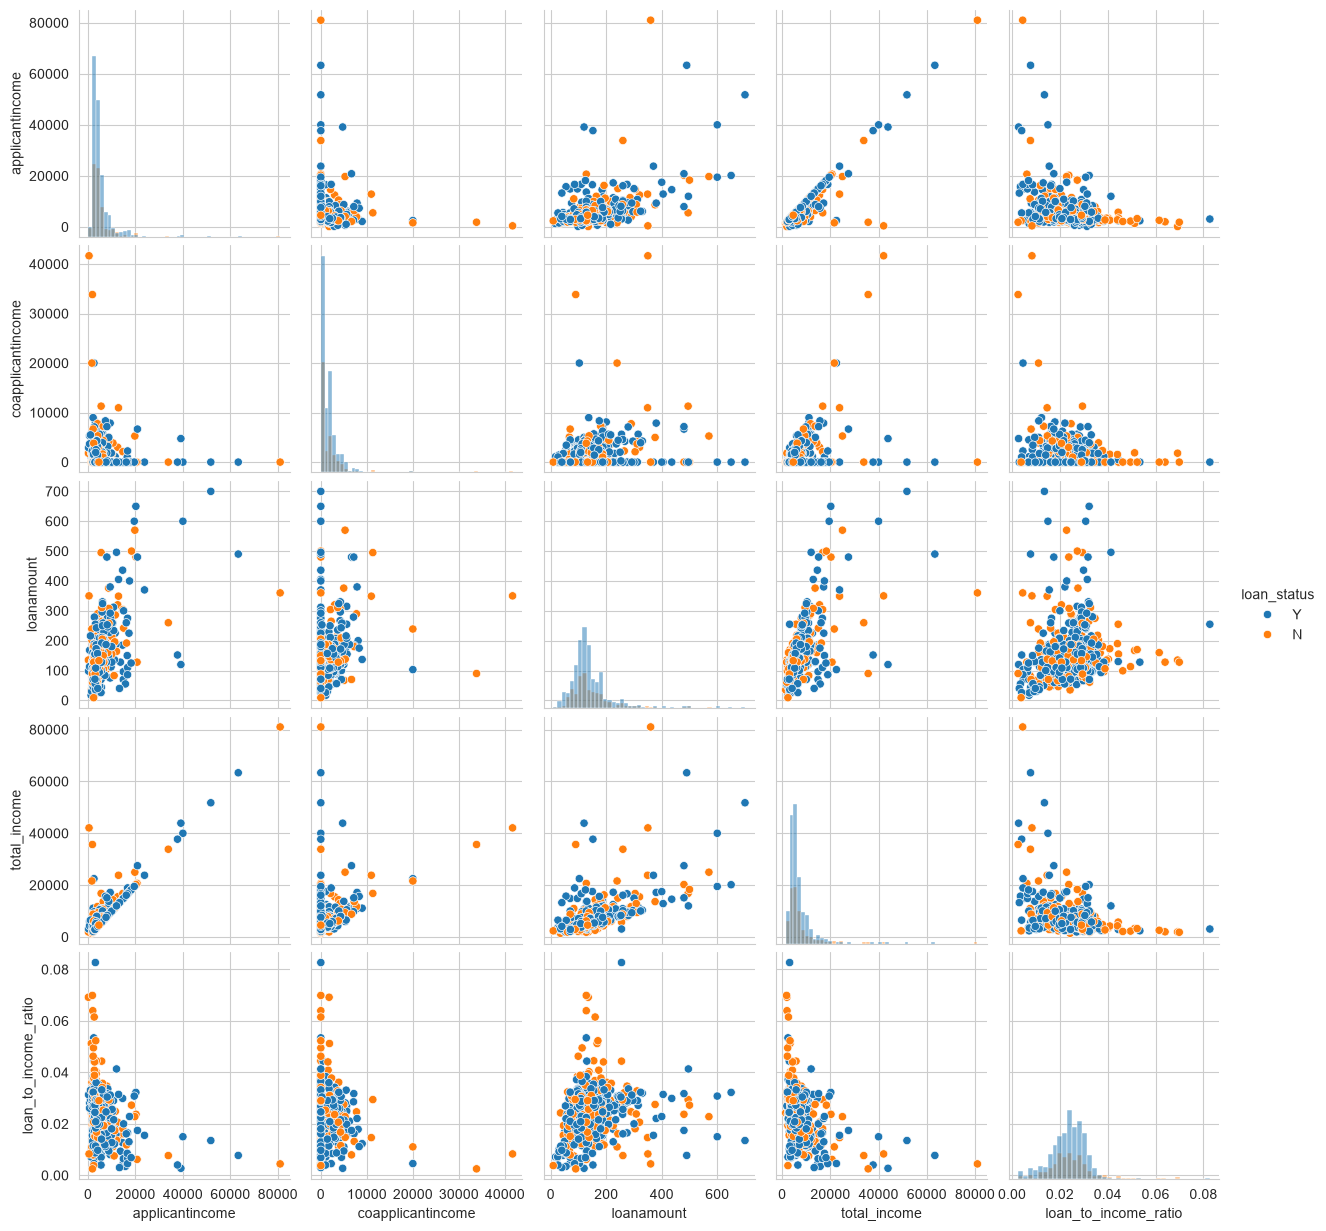

In [115]:
pairplot_columns = [
    "applicantincome",
    "coapplicantincome",
    "loanamount",
    "total_income",
    "loan_to_income_ratio",
    "loan_status"
]
sns.pairplot(
    df[pairplot_columns],
    hue="loan_status",
    diag_kind="hist"
)



plt.show()

## Business Insights
- The pair plot shows a positive relationship between Applicant income and Loan Amount, indicating that applicants with higher incomes generally
tend to apply for larger loan amounts.
- Coapplicant Income shows a weaker relationship with Applicant income and Loan Amount, while most other numerical-variable relationships appear 
relatively weak.
- The distributions also show that most applicants are concentrated in lower-to moderate income and loan-amount ranges, with fewer observations 
at very high ranges.

    

62. Highest Income Applicants

## Step 62: Top 10 Applicants by Total Income
We sort applicants by total income in descending order. This identifies the highest-income applications in the dataset.    



In [117]:
top_income_applicants = (
    df.sort_values(
        "total_income",
        ascending=False
    )

    [    
        [
          "loan_id",
          "applicantincome",
         "coapplicantincome",
          "total_income",
          "loanamount",
            "loan_status"
       ]
  ]
    .head(10)
)    
top_income_applicants

,loan_id,applicantincome,coapplicantincome,total_income,loanamount,loan_status
409,LP002317,81000,0.0,81000.0,360.0,N
333,LP002101,63337,0.0,63337.0,490.0,Y
171,LP001585,51763,0.0,51763.0,700.0,Y
185,LP001640,39147,4750.0,43897.0,120.0,Y
600,LP002949,416,41667.0,42083.0,350.0,N
155,LP001536,39999,0.0,39999.0,600.0,Y
443,LP002422,37719,0.0,37719.0,152.0,Y
581,LP002893,1836,33837.0,35673.0,90.0,N
183,LP001637,33846,0.0,33846.0,260.0,N
506,LP002624,20833,6667.0,27500.0,480.0,Y


63. Largest Loan Applications

## Step 63: Top 10 Largest Loan Applications
We identify applications with the largest requested loan amounts. These applications can be examined as high-value loan cases.  



In [118]:
top_loan_applications = (
    df.sort_values(
        "loanamount",
        ascending=False
    )

    [    
        [
          "loan_id",
          "loanamount",
         "total_income",
          "credit_history",
           "loan_status"           
       ]
  ]
    .head(10)
)    
top_loan_applications

,loan_id,loanamount,total_income,credit_history,loan_status
171,LP001585,700.0,51763.0,1.0,Y
130,LP001469,650.0,20166.0,1.0,Y
561,LP002813,600.0,19484.0,1.0,Y
155,LP001536,600.0,39999.0,0.0,Y
369,LP002191,570.0,24996.0,1.0,N
487,LP002547,500.0,18333.0,1.0,N
604,LP002959,496.0,12000.0,1.0,Y
177,LP001610,495.0,16816.0,0.0,N
333,LP002101,490.0,63337.0,1.0,Y
308,LP001996,480.0,20233.0,1.0,N


64. Rejected with Good Credit History

## Step 64: Rejected Applications with Positive Credit History
We identify rejected applications where the credit-history value is positive. These cases are useful for understanding exceptions and demonstrating that loan approval cannot be explained by a single variable.    



In [119]:
rejected_good_credit = df[
    (df["loan_status"] == "N") &
     (df["credit_history"] == 1)
    ]
rejected_good_credit[
    [

          "loan_id",
          "loanamount",
         "total_income",
          "credit_history",
           "loan_status"           
       ]
  ].head(10)
    

,loan_id,loanamount,total_income,credit_history,loan_status
1,LP001003,128.0,6091.0,1.0,N
9,LP001020,349.0,23809.0,1.0,N
13,LP001029,114.0,4693.0,1.0,N
18,LP001038,133.0,4887.0,1.0,N
24,LP001052,151.0,6642.0,1.0,N
28,LP001086,35.0,1442.0,1.0,N
30,LP001091,201.0,7535.0,1.0,N
31,LP001095,74.0,3167.0,1.0,N
32,LP001097,106.0,4692.0,1.0,N
34,LP001100,320.0,15500.0,1.0,N


65. Approved without Good Credit

## Step 65: Approved Applications Without Positive Credit History
We identify approved applications where the credit-history value is not positive. These are exception cases that may help us understand other characteristics associated with historical approval.    



In [120]:
approved_without_good_credit = df[
    (df["loan_status"] == "Y") &
     (df["credit_history"] != 1)
    ]
approved_without_good_credit[
    [

          "loan_id",
          "total_income",
          "loanamount",
         "credit_history",
           "property_area",
           "loan_status"           
       ]
  ].head(10)
    
        

,loan_id,total_income,loanamount,credit_history,property_area,loan_status
122,LP001431,11117.0,137.0,0.0,Semiurban,Y
155,LP001536,39999.0,600.0,0.0,Semiurban,Y
201,LP001677,4923.0,166.0,0.0,Semiurban,Y
267,LP001882,6144.0,160.0,0.0,Urban,Y
326,LP002068,4917.0,130.0,0.0,Rural,Y
453,LP002449,4949.0,90.0,0.0,Rural,Y
527,LP002706,6715.0,161.0,0.0,Semiurban,Y


66. KPI Summary

## Step 66: Final Business KPI Summary 
We create a concise table containing tthe major metrics from the loan  approval analysis. This provides a numerical summary of the overall dataset. 

  

In [ ]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Applications",
        "Approved Applications",
        "Rejected Applications",
        "Approval Rate(%)",
        "Average Applicant Income",
        "Average coapplicant Income",
        "Average Total Income",
        "Average Loan Amount",
        "Median Loan Amount",
    ],
    "Value": [
        len(df),
        (df["loan_status"] == "Y").sum(),
        (df["loan_status"] == "N").sum(),
        (df["loan_status"] == "Y").mean() *100,
        
df["applicantincome"].mean(),
df["coapplicantincome"].mean(),
        df["total_income"].mean(),
        df["loanamount"].mean(),
         df["loanamount"].median()
    ]
})
kpi_summary

67. Data Quality Check

## Step 67: Final Data Quality Check
Before completing the analysis, we perform a final check of dataset dimensions, missing values, duplicate records, data types.
This ensures that the final analytical dataset is consistent.


In [1]:
print("Final dataset shape:",df.shape)

NameError: name 'df' is not defined

# Final Business Insights
## 1. Loan Approval
The overall approval rate provides th baseline for understanding the historical loan approval pattern in the dataset.

## 2. Credit History
Credit History shows a strong association with historical loan approval. Applicants with positive credit history generally have higher approval rates.

## 3. Property Area 
Approval rates vary across property-area categories, indicating differences in historical approval outcomes across locations.

## 4. Applicant Income
Applicant income provides information about financial capacity, but income alone does not explain every loan approval decision.

## 5. Total Income
Combining applicant and coapplicant income provides a broader measure of recorded household income and allows applicants to be segmented into income
groups.

## 6. Loan-to-Income Ratio
The loan-to-income ratio provides a useful risk-oriented measure by comparing the requested loan with recorded income.

## 7. Multiple Factors
Loan Approval is associated with multiple applicant and loan characteristics. No single variable completely expliains every historical approval outcome.

## 8. Exception Cases
Rejected applicants with positive credit history and approved applicants without positive credit history demonstrate  that historical decisions
cannot be explianed by one variable alone.

## 9. Data Quality
Missing values and duplicate records were identified and handled before the main analysis, improving the quality of the dataset.

## 10. Business Recommendation 

A lender should evaluate applicants using a combination of relevant financial and loan characteristics rather than relying on a single variable.
Historical associations should be validated carefully before being used to make actual lending decisions.



## Final Step: Export the Cleaned Dataset
The cleaned and feature-engineered dataset is exported to CSV.

The exported dataset contains both the original variables and the new analytical variables created during the project.

In [ ]:
df.to_csv("loan_prediction_cleaned.csv", index=False)